In [ ]:
pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 119.2 MB/s eta 0:00:00


In [ ]:
pip install powerlaw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 7.6 MB/s eta 0:00:00


In [ ]:
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, to_hex

In [ ]:
# Create a sample graph
G_n = nx.karate_club_graph() # NetworkX
G_i = ig.Graph.Famous("Zachary") # Igraph

# Distribución de grado



> NetworkX



Degree Centrality: {0: '0.48', 1: '0.27', 2: '0.30', 3: '0.18', 4: '0.09', 5: '0.12', 6: '0.12', 7: '0.12', 8: '0.15', 9: '0.06', 10: '0.09', 11: '0.03', 12: '0.06', 13: '0.15', 14: '0.06', 15: '0.06', 16: '0.06', 17: '0.06', 18: '0.06', 19: '0.09', 20: '0.06', 21: '0.06', 22: '0.06', 23: '0.15', 24: '0.09', 25: '0.09', 26: '0.06', 27: '0.12', 28: '0.09', 29: '0.12', 30: '0.12', 31: '0.18', 32: '0.36', 33: '0.52'}


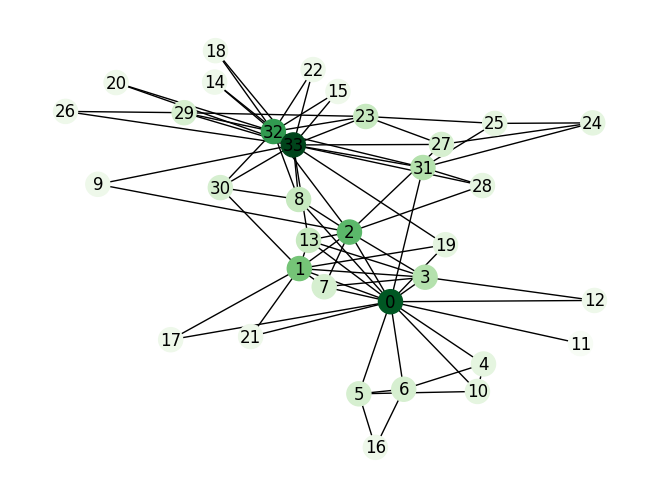

In [ ]:
# Compute degree centrality
degree_centrality = nx.degree_centrality(G_n)

# Print the centrality values with two decimal places
formatted_degree = {node: f'{centrality:.2f}' for node, centrality in degree_centrality.items()}
print("Degree Centrality:", formatted_degree)


# Draw the graph
pos = nx.spring_layout(G_n)
node_colors = [degree_centrality[node] for node in G_n.nodes()]
nx.draw(G=G_n,
        pos=pos,
        with_labels=True,
        node_color=node_colors,
        cmap=plt.cm.Greens)
plt.show()

Uso de bins para mostrar distribuciones


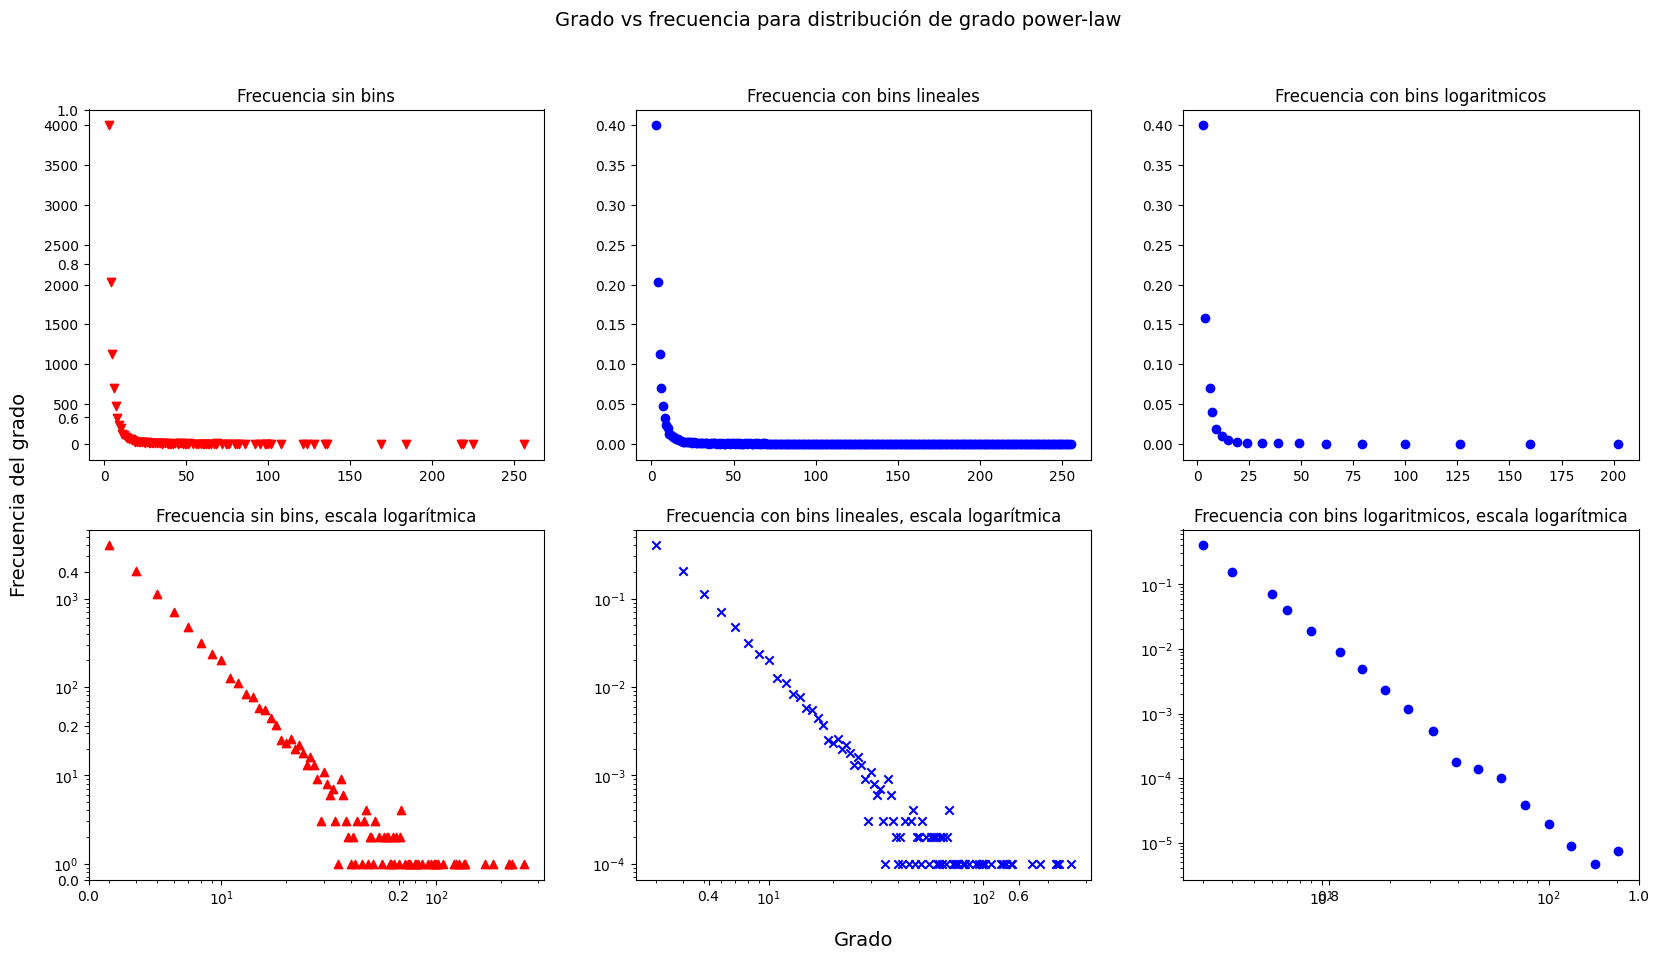

In [ ]:
import powerlaw



def raw_frequency(data: list[float]):
  value_frequency = []
  # sacar valores distintos y ordenarlos
  distinct_values = list(set(data))
  distinct_values.sort()
  # contar valores en data
  for value in distinct_values:
    value_frequency.append(data.count(value))
  return distinct_values, value_frequency

def bin_frequency(data: list[float], logaritmic_bins=False):
  if logaritmic_bins:
    x, y = powerlaw.pdf(data, linear_bins=False)
  else:
    x, y = powerlaw.pdf(data, linear_bins=True)
  x = x[0:-1] # se descarta el último porque es la posición donde iría el siguiente bin
  return x, y


# Vamos a mostrar el caso de una red con distribución de grado power-law para que se noten las diferencias
G = nx.barabasi_albert_graph(10000, 3)
degree_sequence = [d for n, d in G.degree()]
use_data = degree_sequence

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(20, 10))
fig_ax = fig.add_subplot(111, frameon=False)

# mostramos la frecuencia de grado sin bins
x, y = raw_frequency(use_data)
ax1.scatter(x, y, marker='v', c="r")
ax1.title.set_text("Frecuencia sin bins")

# mostramos la frecuencia de grado sin bins, escala logarítmica
x, y = raw_frequency(use_data)
ax4.scatter(x, y, marker='^', c="r")
ax4.title.set_text("Frecuencia sin bins, escala logarítmica")
ax4.loglog()

# mostramos la frecuencia de grado con bins lineales
x, y = bin_frequency(use_data)
ax2.scatter(x, y, marker='o', c="b")
ax2.title.set_text("Frecuencia con bins lineales")

# mostramos la frecuencia de grado con bins lineales, escala logarítmica
x, y = bin_frequency(use_data)
ax5.scatter(x, y, marker='x', c="b")
ax5.loglog()#y usamos escala logarítmica
ax5.title.set_text("Frecuencia con bins lineales, escala logarítmica")

# mostramos la frecuencia de grado con bins logarítmicos
x, y = bin_frequency(use_data, logaritmic_bins=True)
ax3.scatter(x, y, marker='o', c="b")
ax3.title.set_text("Frecuencia con bins logaritmicos")

# mostramos la frecuencia de grado con bins logarítmicos, escala logarítmica
x, y = bin_frequency(use_data, logaritmic_bins=True)
ax6.scatter(x, y, marker='o', c="b")
ax6.title.set_text("Frecuencia con bins logaritmicos, escala logarítmica")
ax6.loglog() #y usamos escala logarítmica
fig.suptitle("Grado vs frecuencia para distribución de grado power-law", fontsize=14)
fig_ax.set_xlabel('Grado', labelpad=20, fontsize=14)
fig_ax.set_ylabel('Frecuencia del grado', labelpad=20, fontsize=14)
plt.show()



> Igraph



Degree Centrality: {0: '0.48', 1: '0.27', 2: '0.30', 3: '0.18', 4: '0.09', 5: '0.12', 6: '0.12', 7: '0.12', 8: '0.15', 9: '0.06', 10: '0.09', 11: '0.03', 12: '0.06', 13: '0.15', 14: '0.06', 15: '0.06', 16: '0.06', 17: '0.06', 18: '0.06', 19: '0.09', 20: '0.06', 21: '0.06', 22: '0.06', 23: '0.15', 24: '0.09', 25: '0.09', 26: '0.06', 27: '0.12', 28: '0.09', 29: '0.12', 30: '0.12', 31: '0.18', 32: '0.36', 33: '0.52'}


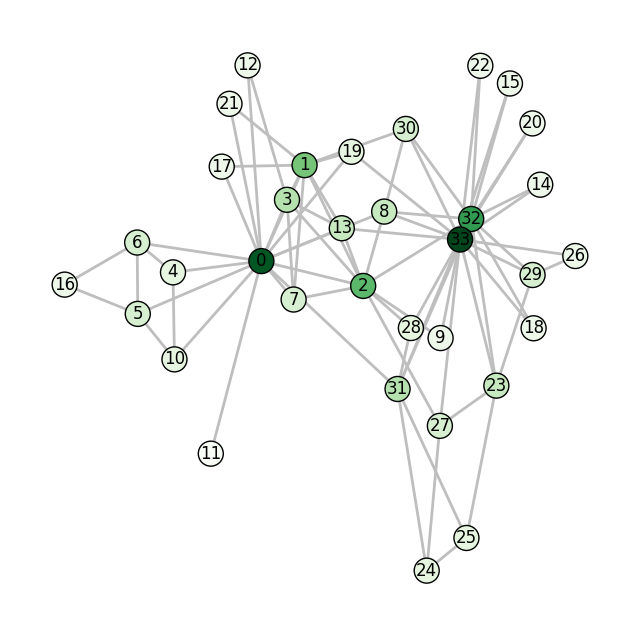

In [ ]:
# Compute degree centrality
degrees = G_i.degree()

degree_centrality = {
    v.index: deg / (G_i.vcount() - 1)
    for v, deg in zip(G_i.vs, degrees)
}

# Print the centrality values with two decimal places
formatted_degree = {
    node: f"{centrality:.2f}"
    for node, centrality in degree_centrality.items()
}
print("Degree Centrality:", formatted_degree)

# Convert centrality values to colors
values = list(degree_centrality.values())

norm = Normalize(vmin=min(values), vmax=max(values))
cmap = cm.Greens

node_colors = [
    to_hex(cmap(norm(degree_centrality[v.index])))
    for v in G_i.vs
]

# Layout
layout = G_i.layout("fr")

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

ig.plot(
    G_i,
    target=ax,
    layout=layout,
    vertex_label=G_i.vs.indices,
    vertex_size=25,
    vertex_color=node_colors,
    vertex_frame_color="black",
    edge_color="gray"
)

plt.show()

# Betweenneess Centrality



> NetworkX



Betweenness Centrality: {0: '0.44', 1: '0.05', 2: '0.14', 3: '0.01', 4: '0.00', 5: '0.03', 6: '0.03', 7: '0.00', 8: '0.06', 9: '0.00', 10: '0.00', 11: '0.00', 12: '0.00', 13: '0.05', 14: '0.00', 15: '0.00', 16: '0.00', 17: '0.00', 18: '0.00', 19: '0.03', 20: '0.00', 21: '0.00', 22: '0.00', 23: '0.02', 24: '0.00', 25: '0.00', 26: '0.00', 27: '0.02', 28: '0.00', 29: '0.00', 30: '0.01', 31: '0.14', 32: '0.15', 33: '0.30'}


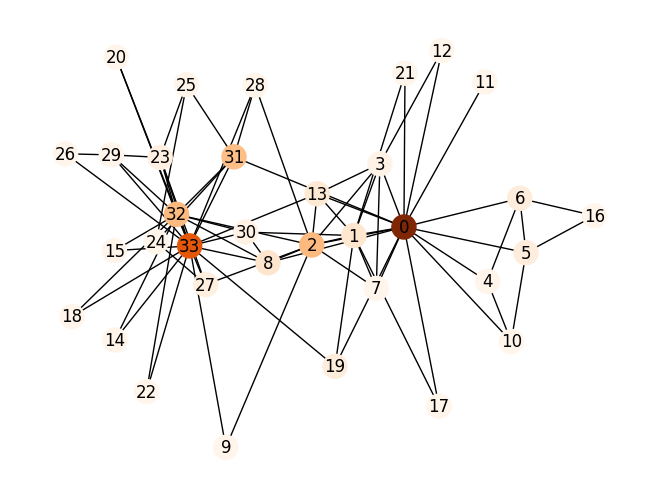

In [ ]:
# Compute betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G_n)

# Print the centrality values
formatted_betweenness = {node: f'{centrality:.2f}' for node, centrality in betweenness_centrality.items()}
print("Betweenness Centrality:", formatted_betweenness)

# Draw the graph
nx.draw(G=G_n,
        pos=pos,
        with_labels=True,
        node_color=list(betweenness_centrality.values()),
        cmap=plt.cm.Oranges)
plt.show()



> Igraph



Betweenness Centrality: {0: '0.44', 1: '0.05', 2: '0.14', 3: '0.01', 4: '0.00', 5: '0.03', 6: '0.03', 7: '0.00', 8: '0.06', 9: '0.00', 10: '0.00', 11: '0.00', 12: '0.00', 13: '0.05', 14: '0.00', 15: '0.00', 16: '0.00', 17: '0.00', 18: '0.00', 19: '0.03', 20: '0.00', 21: '0.00', 22: '0.00', 23: '0.02', 24: '0.00', 25: '0.00', 26: '0.00', 27: '0.02', 28: '0.00', 29: '0.00', 30: '0.01', 31: '0.14', 32: '0.15', 33: '0.30'}


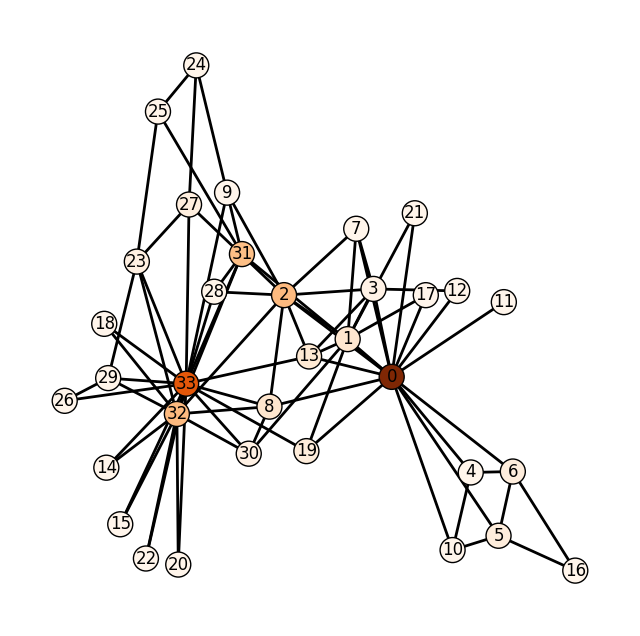

In [ ]:
# Compute betweenness centrality
betweenness = G_i.betweenness()

# Normalize
n = G_i.vcount()
betweenness_centrality = {
    v.index: b / ((n - 1) * (n - 2) / 2)
    for v, b in zip(G_i.vs, betweenness)
}

# Print the centrality values
formatted_betweenness = {
    node: f"{centrality:.2f}"
    for node, centrality in betweenness_centrality.items()
}

print("Betweenness Centrality:", formatted_betweenness)

# Convert values to colors
values = list(betweenness_centrality.values())

norm = Normalize(vmin=min(values), vmax=max(values))
cmap = cm.Oranges

node_colors = [
    to_hex(cmap(norm(betweenness_centrality[v.index])))
    for v in G_i.vs
]

# Layout
layout = G_i.layout("fr")

# Plot graph
fig, ax = plt.subplots(figsize=(8, 8))

ig.plot(
    G_i,
    target=ax,
    layout=layout,
    vertex_label=G_i.vs.indices,
    vertex_size=25,
    vertex_color=node_colors,
    vertex_frame_color="black",
    edge_color="black"
)

plt.show()

# Closeness Centrality



> NetworkX



Closeness Centrality: {0: '0.44', 1: '0.05', 2: '0.14', 3: '0.01', 4: '0.00', 5: '0.03', 6: '0.03', 7: '0.00', 8: '0.06', 9: '0.00', 10: '0.00', 11: '0.00', 12: '0.00', 13: '0.05', 14: '0.00', 15: '0.00', 16: '0.00', 17: '0.00', 18: '0.00', 19: '0.03', 20: '0.00', 21: '0.00', 22: '0.00', 23: '0.02', 24: '0.00', 25: '0.00', 26: '0.00', 27: '0.02', 28: '0.00', 29: '0.00', 30: '0.01', 31: '0.14', 32: '0.15', 33: '0.30'}


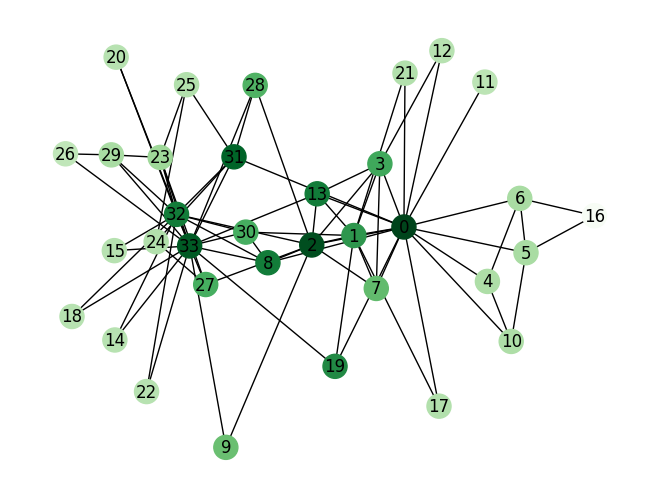

In [ ]:
# Compute closeness centrality
closeness_centrality = nx.closeness_centrality(G_n)

# Print the centrality values
formatted_closeness = {node: f'{centrality:.2f}' for node, centrality in betweenness_centrality.items()}
print("Closeness Centrality:", formatted_closeness)

# Draw the graph
nx.draw(G=G_n,
        pos=pos,
        with_labels=True,
        node_color=list(closeness_centrality.values()),
        cmap=plt.cm.Greens)
plt.show()



> Igraph



Closeness Centrality: {0: '0.57', 1: '0.49', 2: '0.56', 3: '0.46', 4: '0.38', 5: '0.38', 6: '0.38', 7: '0.44', 8: '0.52', 9: '0.43', 10: '0.38', 11: '0.37', 12: '0.37', 13: '0.52', 14: '0.37', 15: '0.37', 16: '0.28', 17: '0.38', 18: '0.37', 19: '0.50', 20: '0.37', 21: '0.38', 22: '0.37', 23: '0.39', 24: '0.38', 25: '0.38', 26: '0.36', 27: '0.46', 28: '0.45', 29: '0.38', 30: '0.46', 31: '0.54', 32: '0.52', 33: '0.55'}


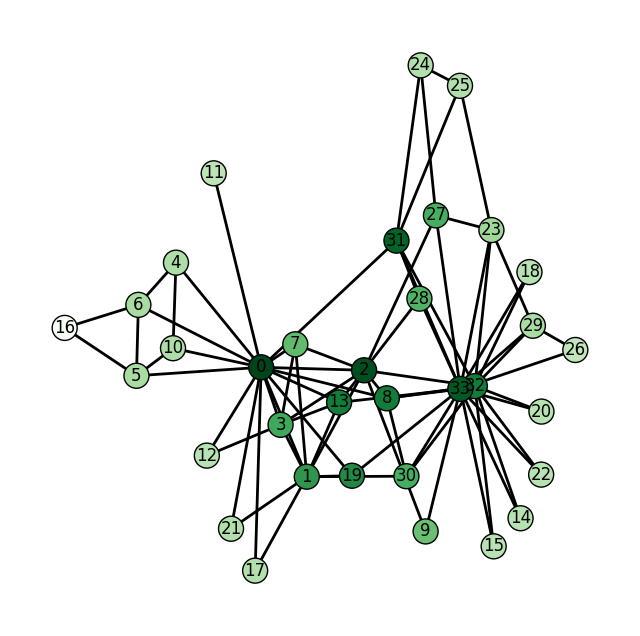

In [ ]:
# Compute closeness centrality
closeness = G_i.closeness()

closeness_centrality = {
    v.index: c
    for v, c in zip(G_i.vs, closeness)
}

# Print the centrality values
formatted_closeness = {
    node: f"{centrality:.2f}"
    for node, centrality in closeness_centrality.items()
}

print("Closeness Centrality:", formatted_closeness)

# Convert values to colors
values = list(closeness_centrality.values())

norm = Normalize(vmin=min(values), vmax=max(values))
cmap = cm.Greens

node_colors = [
    to_hex(cmap(norm(closeness_centrality[v.index])))
    for v in G_i.vs
]

# Layout
layout = G_i.layout("fr")

# Plot graph
fig, ax = plt.subplots(figsize=(8, 8))

ig.plot(
    G_i,
    target=ax,
    layout=layout,
    vertex_label=G_i.vs.indices,
    vertex_size=25,
    vertex_color=node_colors,
    vertex_frame_color="black",
    edge_color="black"
)

plt.show()

# Eigenvector Centrality



> NetworkX



Eigenvector Centrality: {0: '0.36', 1: '0.27', 2: '0.32', 3: '0.21', 4: '0.08', 5: '0.08', 6: '0.08', 7: '0.17', 8: '0.23', 9: '0.10', 10: '0.08', 11: '0.05', 12: '0.08', 13: '0.23', 14: '0.10', 15: '0.10', 16: '0.02', 17: '0.09', 18: '0.10', 19: '0.15', 20: '0.10', 21: '0.09', 22: '0.10', 23: '0.15', 24: '0.06', 25: '0.06', 26: '0.08', 27: '0.13', 28: '0.13', 29: '0.13', 30: '0.17', 31: '0.19', 32: '0.31', 33: '0.37'}


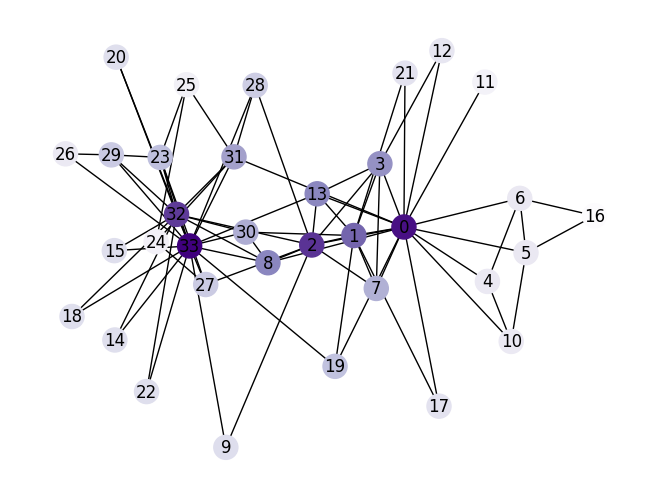

In [ ]:
# Compute eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(G_n)

# Print the centrality values
formatted_eigenvector = {node: f'{centrality:.2f}' for node, centrality in eigenvector_centrality.items()}
print("Eigenvector Centrality:", formatted_eigenvector)


# Draw the graph
nx.draw(G=G_n,
        pos=pos,
        with_labels=True,
        node_color=list(eigenvector_centrality.values()),
        cmap=plt.cm.Purples)
plt.show()



> Igraph



Eigenvector Centrality: {0: '0.95', 1: '0.71', 2: '0.85', 3: '0.57', 4: '0.20', 5: '0.21', 6: '0.21', 7: '0.46', 8: '0.61', 9: '0.27', 10: '0.20', 11: '0.14', 12: '0.23', 13: '0.61', 14: '0.27', 15: '0.27', 16: '0.06', 17: '0.25', 18: '0.27', 19: '0.40', 20: '0.27', 21: '0.25', 22: '0.27', 23: '0.40', 24: '0.15', 25: '0.16', 26: '0.20', 27: '0.36', 28: '0.35', 29: '0.36', 30: '0.47', 31: '0.51', 32: '0.83', 33: '1.00'}


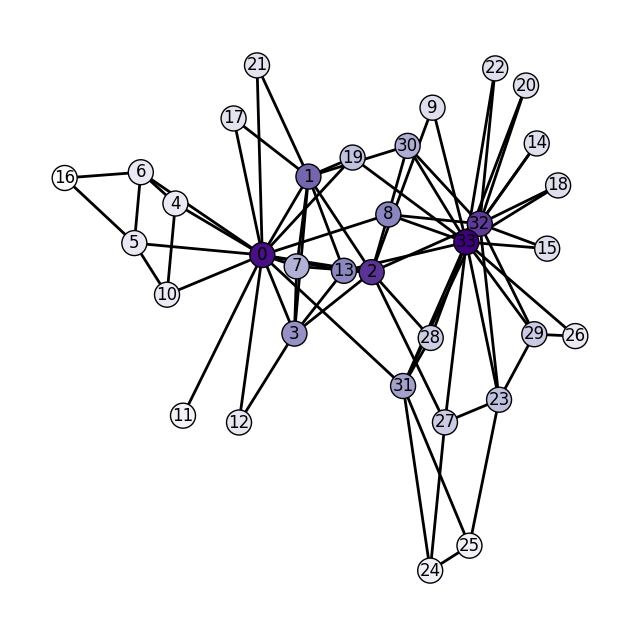

In [ ]:
# Compute eigenvector centrality
eigenvector = G_i.eigenvector_centrality()

eigenvector_centrality = {
    v.index: ev
    for v, ev in zip(G_i.vs, eigenvector)
}

# Print the centrality values
formatted_eigenvector = {
    node: f"{centrality:.2f}"
    for node, centrality in eigenvector_centrality.items()
}

print("Eigenvector Centrality:", formatted_eigenvector)

# Convert values to colors
values = list(eigenvector_centrality.values())

norm = Normalize(vmin=min(values), vmax=max(values))
cmap = cm.Purples

node_colors = [
    to_hex(cmap(norm(eigenvector_centrality[v.index])))
    for v in G_i.vs
]

# Layout
layout = G_i.layout("fr")

# Plot graph
fig, ax = plt.subplots(figsize=(8, 8))

ig.plot(
    G_i,
    target=ax,
    layout=layout,
    vertex_label=G_i.vs.indices,
    vertex_size=25,
    vertex_color=node_colors,
    vertex_frame_color="black",
    edge_color="black"
)

plt.show()

# Clustering Coefficient



> Local and global Clustering Coefficient





> NetworkX



In [ ]:
# Calculate local clustering coefficient
local_clustering = nx.clustering(G_n)

# Format centrality values to two decimal places
formatted_local_clustering = {node: f'{centrality:.2f}' for node,
                           centrality in local_clustering.items()}
print("Local Clustering Coefficient:", formatted_local_clustering)
# Calculate global clustering coefficient
global_clustering = nx.transitivity(G_n)
print("Global Clustering Coefficient:", f"{global_clustering:.2f}")

Local Clustering Coefficient: {0: '0.15', 1: '0.33', 2: '0.24', 3: '0.67', 4: '0.67', 5: '0.50', 6: '0.50', 7: '1.00', 8: '0.50', 9: '0.00', 10: '0.67', 11: '0.00', 12: '1.00', 13: '0.60', 14: '1.00', 15: '1.00', 16: '1.00', 17: '1.00', 18: '1.00', 19: '0.33', 20: '1.00', 21: '1.00', 22: '1.00', 23: '0.40', 24: '0.33', 25: '0.33', 26: '1.00', 27: '0.17', 28: '0.33', 29: '0.67', 30: '0.50', 31: '0.20', 32: '0.20', 33: '0.11'}
Global Clustering Coefficient: 0.26




> Igraph



In [ ]:
# Calculate local clustering coefficient
local_clustering_values = G_i.transitivity_local_undirected()

local_clustering = {
    v.index: coeff
    for v, coeff in zip(G_i.vs, local_clustering_values)
}

# Format values to two decimal places
formatted_local_clustering = {
    node: f"{centrality:.2f}"
    for node, centrality in local_clustering.items()
}

print("Local Clustering Coefficient:", formatted_local_clustering)

# Calculate global clustering coefficient
global_clustering = G_i.transitivity_undirected()

print(
    "Global Clustering Coefficient:",
    f"{global_clustering:.2f}"
)

Local Clustering Coefficient: {0: '0.15', 1: '0.33', 2: '0.24', 3: '0.67', 4: '0.67', 5: '0.50', 6: '0.50', 7: '1.00', 8: '0.50', 9: '0.00', 10: '0.67', 11: 'nan', 12: '1.00', 13: '0.60', 14: '1.00', 15: '1.00', 16: '1.00', 17: '1.00', 18: '1.00', 19: '0.33', 20: '1.00', 21: '1.00', 22: '1.00', 23: '0.40', 24: '0.33', 25: '0.33', 26: '1.00', 27: '0.17', 28: '0.33', 29: '0.67', 30: '0.50', 31: '0.20', 32: '0.20', 33: '0.11'}
Global Clustering Coefficient: 0.26




> NetworkX



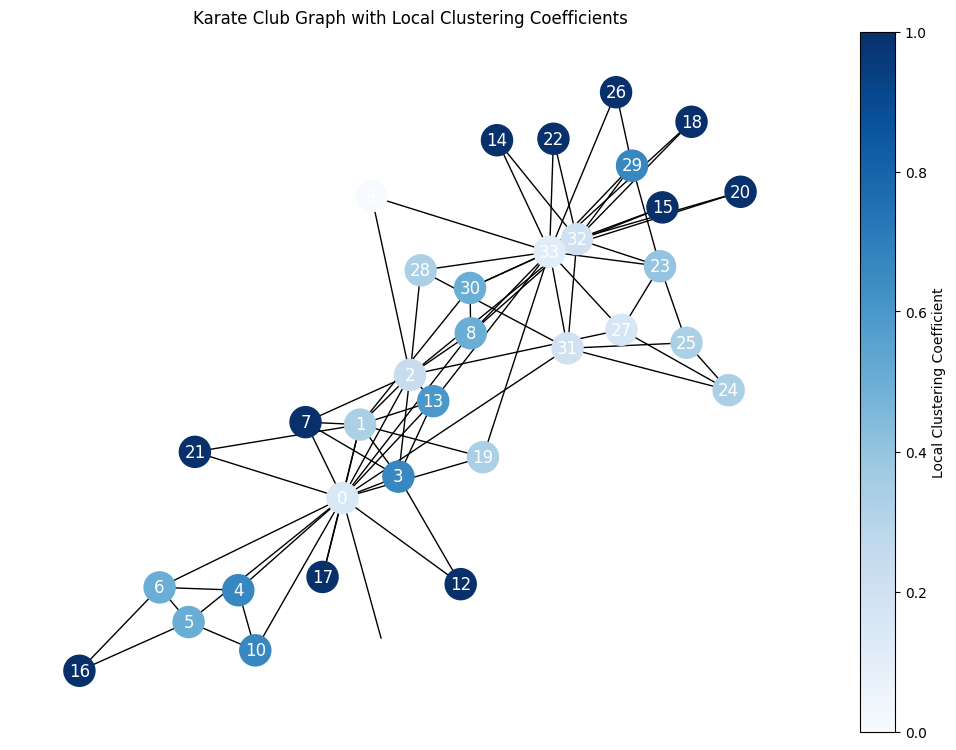

In [ ]:
# Visualize the local clustering coefficients
node_colors = [local_clustering[node] for node in G_n.nodes]
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_n)
nodes = nx.draw(G_n,
                pos,
                node_color=node_colors,
                with_labels=True,
                cmap=plt.cm.Blues,
                node_size=500,
                font_color='white')

# Create a colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues,
                           norm=plt.Normalize(vmin=min(node_colors),
                                              vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), label="Local Clustering Coefficient")
plt.title("Karate Club Graph with Local Clustering Coefficients")
plt.show()

# Average Path Length



> Calculating Average Path Length:





> NetworkX



In [ ]:
# Calculate average path length
average_path_length = nx.average_shortest_path_length(G_n)
print("Average Path Length:", f"{average_path_length:.2f}")



> Igraph



In [ ]:
# Calculate average path length
average_path_length = G_i.average_path_length()
print("Average Path Length:", f"{average_path_length:.2f}"
)